**Clickstream SQL Project Data Analysis**

Questions I want to answer:

*   What user behavior is more likely to lead to a purchase?
*   What user behavior is more likely to lead to churn?
*   When and why do users drop out?






I decided to first look at the single session and their components. A straight line user journey would be page/ product view - add product to cart - checkout - purchase.

In [ ]:
SELECT
  ROUND((COUNT(products_viewed)/COUNT(session_id))*100,2) AS pct_viewed,
  ROUND((COUNT(products_added)/COUNT(session_id))*100,2) AS pct_added,
  ROUND((COUNT(products_checkout)/COUNT(session_id))*100,2) AS pct_checkout,
  ROUND((COUNT(products_purchased)/COUNT(session_id))*100,2) AS pct_purchased
FROM `clickstream-sql-project.clickstream.sessions`

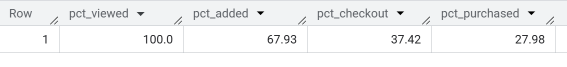

There are only 4 event types: page_view (equals product_view), add_to_cart, checkout and purchase.

Considering this, it makes sense that pct_viewed will always be 100%

In [ ]:
SELECT
  outcome,
  ROUND((COUNT(products_viewed)/COUNT(session_id))*100,2) AS pct_viewed,
  ROUND((COUNT(products_added)/COUNT(session_id))*100,2) AS pct_added,
  ROUND((COUNT(products_checkout)/COUNT(session_id))*100,2) AS pct_checkout,
  ROUND((COUNT(products_purchased)/COUNT(session_id))*100,2) AS pct_purchased
FROM `clickstream-sql-project.clickstream.sessions`
GROUP BY outcome

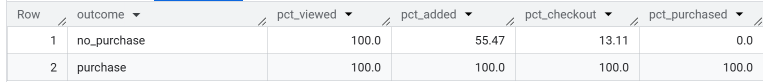

As expected the purchase row has 100% over all metrics.
All sessions with the outcome purchase are required to end up with a purchase.

What this tells us:

*  From all sessions, only 27.98% end up with a purchase.
*  32.07% of all sessions end without adding products to the cart
    -> This suggests that session users did not have a product level intent, or did not find a product of interest.
*  More than half (55.47%) of sessions that don't lead to a purchase, still add products to their cart and 13.11% checkout -> Why do these session users drop out, even though they are interested in a purchase?








In [ ]:
SELECT
  last_event,
  COUNT(last_event) AS drop_off_after_event,
  ROUND((COUNT(last_event)/SUM(COUNT(last_event)) OVER())*100,2) AS pct_drop_off
FROM `clickstream-sql-project.clickstream.sessions`
WHERE outcome = 'no_purchase'
  AND products_added IS NOT NULL
GROUP BY last_event
ORDER BY drop_off_after_event DESC

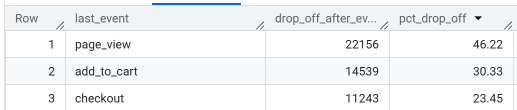

Looking at sessions with product-intent (at least one product was added to the cart), we see:
*   46.22% drop off after viewing a product -> are they viewing different products than in the cart and experience 'browsing fatigue'? Do they check on the product in their cart again and decide not buying it?
*  30.33% drop off after they added a product to their cart -> there could be a multitude of reasons, they might compare to other products on other websites or leave it in their cart for later (did users that initally dropped out after they added a product come back later and buy the product?)
*   23.45% drop off after checkout -> though there is a strong intent, purchase does not happen? Reasons could be price, payment friction, unexpected fees etc.

For now I focus on the drop offs after checkout. Getting to this stage suggests a strong purchase intent, so is there a reason why users drop out here? The dataset doesn't allow to check on prices (no amount unless a purchase happened). But I can at least look at the product information.



To understand buying intent, I double checked and everyone who ended up at checkout had at least on product added, which makes sense as you wouldn't check out an empty cart. It also suggests that the user journey is probably linear in this dataset (to be checked later).

In [ ]:
SELECT
  last_event,
  COUNT(last_event)
FROM `clickstream-sql-project.clickstream.sessions`
WHERE products_added IS NULL
GROUP BY last_event

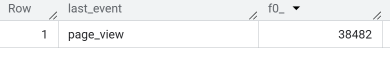

Could the amounts of products in the cart be an indicator for drop outs at the checkout stage?

In [ ]:
SELECT
  ROUND(AVG(CASE WHEN last_event[ORDINAL(1)] = 'purchase'
            THEN products_checkout END),2) AS avg_products_purchase,
  ROUND(AVG(CASE WHEN last_event[ORDINAL(1)] = 'checkout'
            THEN products_checkout END),2)AS avg_products_checkout,
FROM `clickstream-sql-project.clickstream.sessions`
# I first ran without ORDINAL(1) and got an error "No matching signature for operator = for argument types: ARRAY<STRING>"
# In hindsight I should have used ORDINAL(1) when creating the table, as I can't update the table (restrictions of free Big Query account)
# As I didn't, I'm now dealing with arrays and always have to call the first element so I actually get a string...

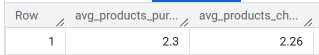

Averages don't show us anything right here. Might be too blunt to use as metric, I will define buckets with cart sizes instead and see if this gives me any insights.

In [ ]:
SELECT
  products_checkout,
  COUNT(products_checkout)
FROM `clickstream-sql-project.clickstream.sessions`
GROUP BY products_checkout

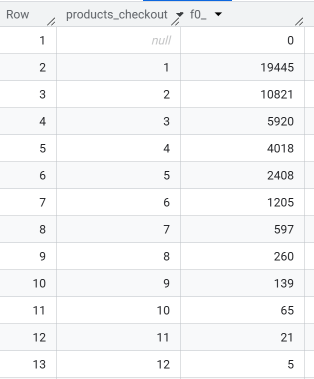

Based on the distribution it makes sense to create 6 buckets 1 product to 6+ products.

In [ ]:
SELECT
  CASE WHEN products_checkout = 1 THEN '1 Product'
     WHEN  products_checkout = 2 THEN '2 Products'
     WHEN  products_checkout = 3 THEN '3 Products'
     WHEN  products_checkout = 4 THEN '4 Products'
     WHEN  products_checkout = 5 THEN '5 Products'
     WHEN  products_checkout >= 6 THEN '6+ Products' END AS cart_size,
  COUNTIF(last_event[ORDINAL(1)]='checkout') AS checkout,
  COUNTIF(last_event[ORDINAL(1)]='purchase') AS purchase,
  ROUND(
    (COUNTIF(last_event[ORDINAL(1)]='checkout')/
    SUM(COUNTIF(last_event[ORDINAL(1)]='checkout')) OVER ()) *100,2)
    AS drop_off_pct_checkout,
  ROUND(
    (COUNTIF(last_event[ORDINAL(1)]='purchase')/
    SUM(COUNTIF(last_event[ORDINAL(1)]='purchase')) OVER ())*100,2)
    AS drop_off_pct_purchase
FROM `clickstream-sql-project.clickstream.sessions`
WHERE last_event[ORDINAL(1)] IN ('checkout', 'purchase')
GROUP BY cart_size
ORDER BY cart_size

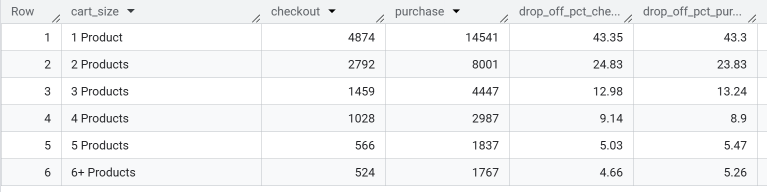

The distribution of drop off rates over the buckets, are nearly the same for checkout-drop-offs and purchases. So cart size alone does not explain drop offs after check out.

Next I will check if sessions drop off more often for specific products.
Product IDs are only associated with the events page_view and add_to_cart, so I will have to use the events table as well.

In [ ]:
# CTE to only filter for sessions that droped off after checkout
WITH checkout_drop_offs AS (
  SELECT session_id
  FROM `clickstream-sql-project.clickstream.sessions`
  WHERE last_event[ORDINAL(1)] = 'checkout')

# Calling the product ids from 'add to cart' events
# But only for sessions that dropped off after checkout
SELECT
  e.product_id,
  COUNT(e.product_id) AS total_count,
  ROUND(
      (COUNT(e.product_id)/
       SUM(COUNT(e.product_id)) OVER())*100,2) AS pct_drop_off
FROM `clickstream-sql-project.clickstream.events` e
RIGHT JOIN checkout_drop_offs cdo
  ON e.session_id = cdo.session_id
WHERE e.event_type = 'add_to_cart'
GROUP BY e.product_id
ORDER BY COUNT(e.product_id) DESC

Top 10 Output rows:
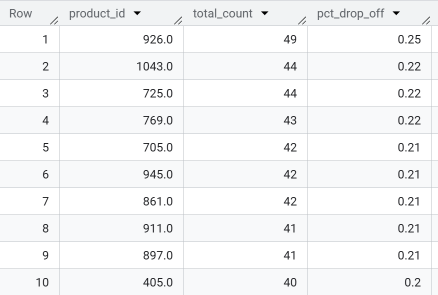

Bottom 10 Output rows: 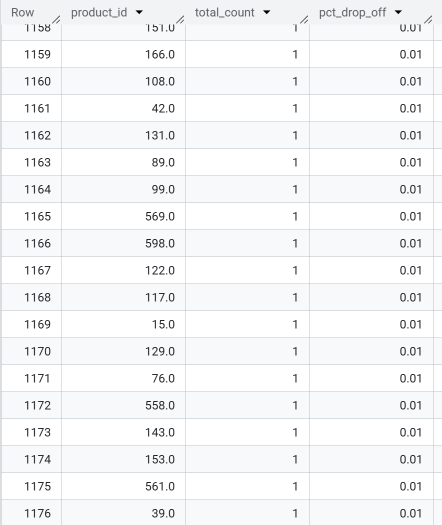

While some products appear more frequently in checkout drop-off sessions, this alone does not indicate that these products cause the actual drop off. Since I only considered drop-off sessions, higher percentages only reflect that these products are added to cart more often. What I missed in this last query, is a comparison to how often the products are added to the cart and purchased.

I will continute at products added in general, not the quantity added within a single event. The buying intention counts for this analysis, so it does not matter if the user intended to buy or bought the same product several times.

In [ ]:
# Create CTE with the product count for sessions ending with a purchase
WITH purchase_products AS(
  SELECT
    e.product_id,
    COUNT(*) AS purchase_cnt
  FROM `clickstream-sql-project.clickstream.events` e
  JOIN `clickstream-sql-project.clickstream.sessions` s
    ON e.session_id = s.session_id
  WHERE s.last_event[ORDINAL(1)] = 'purchase'
    AND e.event_type = 'add_to_cart'
  GROUP BY e.product_id),
# Create CTE with the product count for sessions ending with a drop off
  dropoff_products AS(
    SELECT
    e.product_id,
    COUNT(*) AS dropoff_cnt
  FROM `clickstream-sql-project.clickstream.events` e
  JOIN `clickstream-sql-project.clickstream.sessions` s
    ON e.session_id = s.session_id
  WHERE s.last_event[ORDINAL(1)] = 'checkout'
    AND e.event_type = 'add_to_cart'
  GROUP BY e.product_id
  )

# Combine the counts and calculate the percentage of drop offs
SELECT
  p.product_id,
  p.purchase_cnt,
  d.dropoff_cnt,
  ROUND((d.dropoff_cnt/(p.purchase_cnt+d.dropoff_cnt))*100,2) AS drop_pct
FROM purchase_products p
FULL JOIN dropoff_products d
ON p.product_id = d.product_id
ORDER BY drop_pct DESC

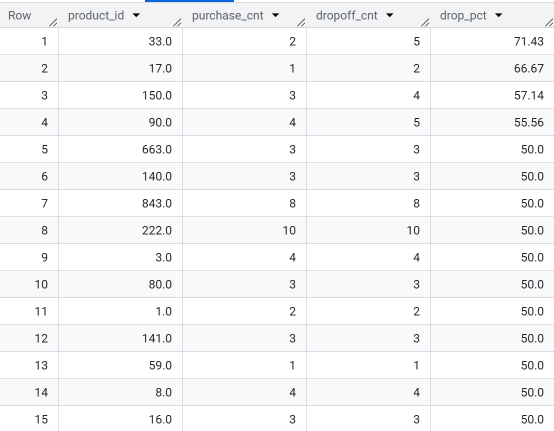

Some products show very high drop off rates, however, the product counts have very low volumes and are therefore not statistically meaningful. To focus on actionable insights, I will filter for products with an add to cart volume that is higher than 100

In [ ]:
# Create CTE with the product count for sessions ending with a purchase
WITH purchase_products AS(
  SELECT
    e.product_id,
    COUNT(*) AS purchase_cnt
  FROM `clickstream-sql-project.clickstream.events` e
  JOIN `clickstream-sql-project.clickstream.sessions` s
    ON e.session_id = s.session_id
  WHERE s.last_event[ORDINAL(1)] = 'purchase'
    AND e.event_type = 'add_to_cart'
  GROUP BY e.product_id),
# Create CTE with the product count for sessions ending with a drop off
  dropoff_products AS(
    SELECT
    e.product_id,
    COUNT(*) AS dropoff_cnt
  FROM `clickstream-sql-project.clickstream.events` e
  JOIN `clickstream-sql-project.clickstream.sessions` s
    ON e.session_id = s.session_id
  WHERE s.last_event[ORDINAL(1)] = 'checkout'
    AND e.event_type = 'add_to_cart'
  GROUP BY e.product_id
  )

# Combine the counts and calculate the percentage of drop offs
SELECT
  p.product_id,
  p.purchase_cnt,
  d.dropoff_cnt,
  ROUND((d.dropoff_cnt/(p.purchase_cnt+d.dropoff_cnt))*100,2) AS drop_pct
FROM purchase_products p
FULL JOIN dropoff_products d
ON p.product_id = d.product_id
WHERE (p.purchase_cnt+d.dropoff_cnt) > 100
ORDER BY drop_pct DESC

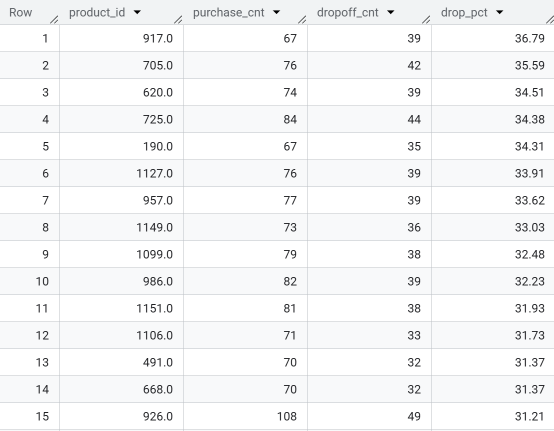

The drop_pct range between 36.79% and 13.59%.

If this would be a real-life project, I would export a list of all products that have a drop off percentage higher than average, so the products team can check on these products (reviews, price comparison with competitors etc.). This doesn't mean that anything is wrong with the products, but there might be a reason on why their drop off rate is higher than others.

Using my query above to calculate the average.

In [ ]:
WITH purchase_products AS(
  SELECT
    e.product_id,
    COUNT(*) AS purchase_cnt
  FROM `clickstream-sql-project.clickstream.events` e
  JOIN `clickstream-sql-project.clickstream.sessions` s
    ON e.session_id = s.session_id
  WHERE s.last_event[ORDINAL(1)] = 'purchase'
    AND e.event_type = 'add_to_cart'
  GROUP BY e.product_id),

  dropoff_products AS(
    SELECT
    e.product_id,
    COUNT(*) AS dropoff_cnt
  FROM `clickstream-sql-project.clickstream.events` e
  JOIN `clickstream-sql-project.clickstream.sessions` s
    ON e.session_id = s.session_id
  WHERE s.last_event[ORDINAL(1)] = 'checkout'
    AND e.event_type = 'add_to_cart'
  GROUP BY e.product_id
  )

SELECT
  AVG((d.dropoff_cnt/(p.purchase_cnt+d.dropoff_cnt))*100) AS avg_drop_pct
FROM purchase_products p
FULL JOIN dropoff_products d
ON p.product_id = d.product_id
WHERE (p.purchase_cnt+d.dropoff_cnt) > 100


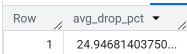

There are still some metrics within the session data, that I haven't looked at, that might help to understand why sessions users with strong buying intent drop out after checkout. One being session length.

Does the session length of drop off after checkout sessions differ from session length of sessions that lead to a purchase?

I will first create buckets for the session lengths. To get an idea for bucket size, I look at basic values: minimum, maximum and average.



In [ ]:
SELECT
  MIN(session_length) AS minimum,
  MAX(session_length) AS maximum,
  AVG(session_length) AS average
FROM `clickstream-sql-project.clickstream.sessions`

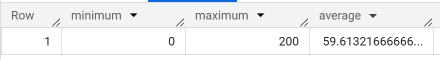

To work with buckets that are the same length, I opt for 25 minutes increments, which also seems to be a good length thinking about online shopping and browsing in real life.

In [ ]:
SELECT
  CASE
   WHEN session_length BETWEEN 0 AND 25 THEN '0-25 min'
   WHEN session_length BETWEEN 26 AND 50 THEN '26-50 min'
   WHEN session_length BETWEEN 51 AND 75 THEN '51-75 min'
   WHEN session_length BETWEEN 76 AND 100 THEN '76-100 min'
   WHEN session_length BETWEEN 101 AND 125 THEN '101-125 min'
   WHEN session_length BETWEEN 126 AND 150 THEN '126-150 min'
   WHEN session_length BETWEEN 151 AND 175 THEN '151-175 min'
   WHEN session_length BETWEEN 176 AND 200 THEN '176-200 min'
  END AS session_length,
  ROUND(
    (COUNTIF(last_event[ORDINAL(1)]='checkout')/
    SUM(COUNTIF(last_event[ORDINAL(1)]='checkout')) OVER ()) *100,2)
    AS drop_off_pct_checkout,
  ROUND(
    (COUNTIF(last_event[ORDINAL(1)]='purchase')/
    SUM(COUNTIF(last_event[ORDINAL(1)]='purchase')) OVER ())*100,2)
    AS drop_off_pct_purchase
FROM `clickstream-sql-project.clickstream.sessions`
WHERE last_event[ORDINAL(1)] IN ('checkout', 'purchase')
GROUP BY session_length
ORDER BY session_length

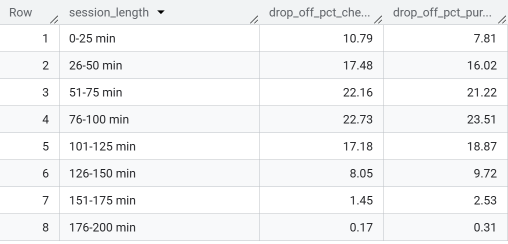

There is not a notable difference between the sessions lengths and drop offs/ purchases. The biggest differenct is within the first interval, but it seems obvious that there are less purchases within the first 25 minutes than drop offs.

Next I will check if the total number of events within a session seems to influence buying behaviour. Again, I'm planning to create some buckets, based on the minimum, maximum and average.


In [ ]:
SELECT
  MIN(total_events) AS min_events,
  MAX(total_events) AS max_events,
  AVG(total_events) AS avg_events
FROM `clickstream-sql-project.clickstream.sessions`
WHERE last_event[ORDINAL(1)] IN ('checkout','purchase')

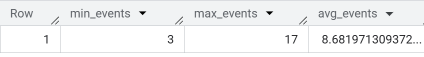

The minimun number of events to be considered a drop-off session after checkout is 3 (page_view, add_to_cart, checkout). The min, max and avg make it hard to determine a good size for the buckets, so I will look at the total distribution. Maybe there are some total event counts that I can group together.

In [ ]:
SELECT
  total_events,
  COUNT(total_events) AS count_events
FROM `clickstream-sql-project.clickstream.sessions`
WHERE last_event[ORDINAL(1)] IN ('purchase', 'checkout')
GROUP BY total_events

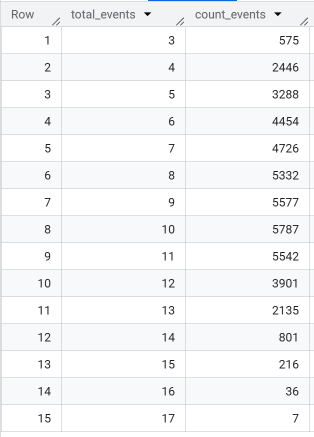

The count for sessions with more than 13 events drops a lot, so I can create the last bucket as 13+.

In [ ]:
SELECT
  CASE
    WHEN total_events = 3 THEN '3 events'
    WHEN total_events = 4 THEN '4 events'
    WHEN total_events = 5 THEN '5 events'
    WHEN total_events = 6 THEN '6 events'
    WHEN total_events = 7 THEN '7 events'
    WHEN total_events = 8 THEN '8 events'
    WHEN total_events = 9 THEN '9 events'
    WHEN total_events = 10 THEN '10 events'
    WHEN total_events = 11 THEN '11 events'
    WHEN total_events = 12 THEN '12 events'
    WHEN total_events > 12 THEN '13+ events'
  END AS number_of_events,
  ROUND(
    (COUNTIF(last_event[ORDINAL(1)]='checkout')/
    SUM(COUNTIF(last_event[ORDINAL(1)]='checkout')) OVER ()) *100,2)
    AS drop_off_pct_checkout,
  ROUND(
    (COUNTIF(last_event[ORDINAL(1)]='purchase')/
    SUM(COUNTIF(last_event[ORDINAL(1)]='purchase')) OVER ())*100,2)
    AS drop_off_pct_purchase
FROM `clickstream-sql-project.clickstream.sessions`
WHERE last_event[ORDINAL(1)] IN ('checkout', 'purchase')
GROUP BY number_of_events

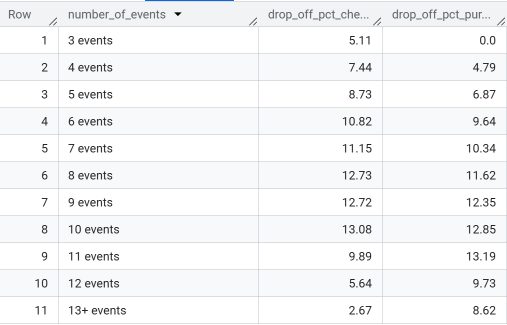

It makes sense that there are not purchases with only 3 events. And that drop offs are slightly higher with less events. However for a total event count of 6 to 10 events the percentage of drop offs and purchases is very similar. So sessions that drop off after checkout are not necessarily less engaged. As amount of products added to the cart,  session length and even count of events (which can be seen as an engagement meassure) don't have a clear influence on drop offs, there might be something wrong with the checkout process itself.

Would this be a real-life analysis, I'd reach out to the website team to check if there are either technical issues, extended load times etc. Or if there might be other "turn offs" like high shipping costs, force account creation or limitations in payment methods.

Next, I will look at the user data. Are there patterns in user behaviour of users that have a low conversion rate vs a high conversion rate?
I will use buckets with increments of 20% to group the users based on conversion rate.

In [ ]:
SELECT
  CASE
    WHEN conversion_rate < 20 THEN 'Low buyer'
    WHEN conversion_rate BETWEEN 20 AND 39 THEN 'Occasional buyer'
    WHEN conversion_rate BETWEEN 40 AND 59 THEN 'Moderate buyer'
    WHEN conversion_rate BETWEEN 60 AND 79 THEN 'Frequent buyer'
    WHEN conversion_rate >= 80 THEN 'Super buyer'
  END AS buyer_type,
  COUNT(user_id) AS bucket_size,
  MIN(total_sessions) AS min_sessions,
  MAX(total_sessions)AS max_sessions,
  ROUND(AVG(total_sessions),2) AS avg_sessions,
  MIN(total_time_spent)AS min_time_spent,
  MAX(total_time_spent)AS max_time_spent,
  ROUND(AVG(total_time_spent),2) AS avg_time_spent,
  ROUND(AVG(total_products_viewed),2) AS avg_prod_viewed,
  ROUND(AVG(total_products_added),2) AS avg_prod_added,
  ROUND(AVG(total_products_checkout),2) AS avg_prod_checkout,
  ROUND(AVG(total_products_purchased),2) AS avg_prod_purchased,
  ROUND(AVG(amount_user),2) AS avg_amount_spent
FROM `clickstream-sql-project.clickstream.users`
GROUP BY buyer_type

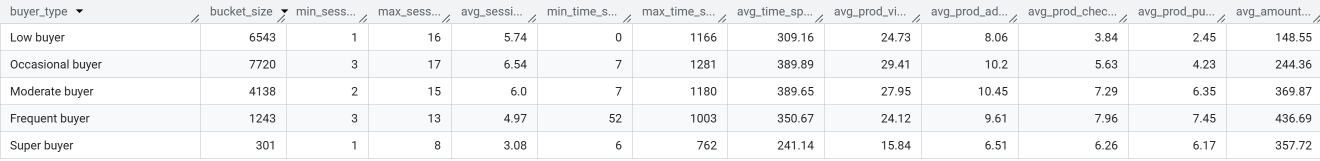

There are some interesting trends here:

*  Frequent buyers have a very high "minimum time spent" of 52 minutes:
    When analyzing on session level, the length did not seem to have any impact on purchase behaviour, but maybe users that spend more time on the website in general are more likely to buy something?
*  Low buyers are still adding quite a big amount of products on average (8.  05), but only end up buying 2.45 on average.
*   Moderate, frequent and super buyers keep more products till the end (and purchase them) in comparison to low and occasional buyers
*  Super buyers is a small buyer group but they seem to know what they want. They have the least amount of sessions, shortes time spent (in max and avg), they view less products than the other buyer groups, and average product added to average product purchased only drops by 0.34
*   The two biggest groups are low and occasional buyers

Based on this, I want to see the last_events grouped by the different buyer_types. Where do the buyer_types drop off most frequently?







In [ ]:
SELECT
  CASE
    WHEN conversion_rate < 20 THEN 'Low buyer'
    WHEN conversion_rate BETWEEN 20 AND 39 THEN 'Occasional buyer'
    WHEN conversion_rate BETWEEN 40 AND 59 THEN 'Moderate buyer'
    WHEN conversion_rate BETWEEN 60 AND 79 THEN 'Frequent buyer'
    WHEN conversion_rate >= 80 THEN 'Super buyer'
  END AS buyer_type,
  ROUND((COUNTIF(last_event[ORDINAL(1)]='page_view')/COUNT(s.session_id))*100,2) AS do_view,
  ROUND((COUNTIF(last_event[ORDINAL(1)]='add_to_cart')/COUNT(s.session_id))*100,2) AS do_add,
  ROUND((COUNTIF(last_event[ORDINAL(1)]='checkout')/COUNT(s.session_id))*100,2) AS do_checkout,
  ROUND((COUNTIF(last_event[ORDINAL(1)]='purchase')/COUNT(s.session_id))*100,2) AS purchase
FROM `clickstream-sql-project.clickstream.users` u
FULL JOIN `clickstream-sql-project.clickstream.sessions` s
ON u.user_id = s.user_id
GROUP BY buyer_type

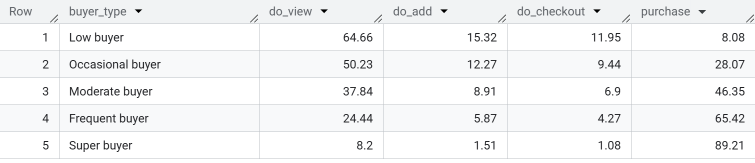

More than 50% of sessions from low and occasional buyers drop off after page views, indicating mostly browsing behavior. Marketing could target these users with personalized emails highlighting new products or promotions to encourage conversion.


Next, I will look at user behaviour based on session count. Are users with more sessions more likely to end up purchasing something?

In [ ]:
SELECT
  total_sessions,
  COUNT(total_sessions)
FROM `clickstream-sql-project.clickstream.users`
GROUP BY
total_sessions

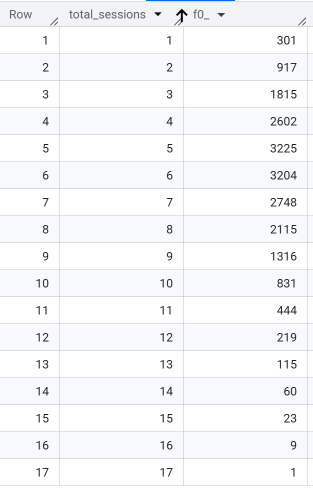

In [ ]:
SELECT
  CASE
    WHEN total_sessions <3 THEN '<3 sessions'
    WHEN total_sessions = 3 THEN '3 sessions'
    WHEN total_sessions = 4 THEN '4 sessions'
    WHEN total_sessions = 5 THEN '5 sessions'
    WHEN total_sessions = 6 THEN '6 sessions'
    WHEN total_sessions = 7 THEN '7 sessions'
    WHEN total_sessions = 8 THEN '8 sessions'
    WHEN total_sessions = 9 THEN '9 sessions'
    WHEN total_sessions > 9 THEN '10+ sessions'
  END AS session_buckets,
  COUNT(user_id) AS bucket_size,
  MIN(total_time_spent) AS min_time_spent,
  MAX(total_time_spent)AS max_time_spent,
  ROUND(AVG(total_time_spent),2) AS avg_time_spent,
  ROUND(AVG(total_products_viewed),2) AS avg_prod_viewed,
  ROUND(AVG(total_products_added),2) AS avg_prod_added,
  ROUND(AVG(total_products_checkout),2) AS avg_prod_checkout,
  ROUND(AVG(total_products_purchased),2) AS avg_prod_purchased,
  ROUND(AVG(amount_user),2) AS avg_amount_spent,
  MIN(conversion_rate) AS min_conversion,
  MAX(conversion_rate) AS max_conversion,
  ROUND(AVG(conversion_rate),2) AS avg_conversion
FROM `clickstream-sql-project.clickstream.users`
GROUP BY session_buckets

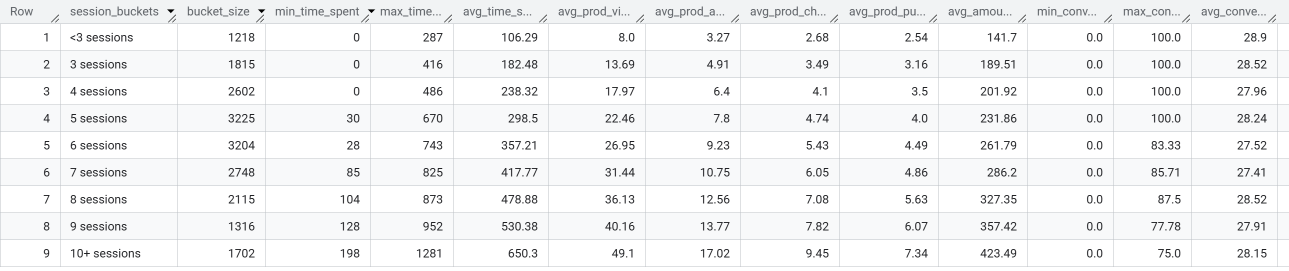

This shows that spending more time on the site or having more sessions does not automatically lead to a higher conversion rate per session. Users with more sessions do buy more products and spend more overall, but the max conversion rate indicates that their purchases are spread across sessions rather than happening in every session.

So higher session counts accumulate revenue rather than increasing session-level conversion. I'd suggest to improve per-session conversion for frequent users, for example with targeted recommendations or incentives during visits.

**Summary**

Drop-offs after checkout are not explained by session length, cart size, or number of events, suggesting potential friction in the checkout process.

Recommendations:
*   Investigate checkout friction (UX issues? Maybe A/B testing for different checkout versions)
*   Review products with high drop off rates (price competitiveness, user reviews, product information etc.)
*   Encourage purchase completion (reminder emails that products are checked out put not purchased)

The majority of users are low and occasional buyers. They add products to their carts but don't buy them.

Recommendations:
*   Targeted marketing campaigns for these users specifically
*   Analyze browsing path (ddep-dive into browsing paths to find pain and friction points that might stop these users from a purchase)

Conversion rate per session does not automatically increase with more sessions. Higher session counts correlate with more products purchased and higher total revenue, but not higher per-session conversion.

Recommendations:
*   Maximize per-session conversion (personalized recommendations, limited-time discounts etc.)
*   Marketing campaigns to keep users come back (personalized recommendations, discounts etc.)




